# MLP Project : Comment Category Prediction Challenge
## Name : Kartik bajaj
## Roll number : 24f2007692

# Milestone 1: EDA,Preprocessing and Baseline Model
- Data loading
- EDA
- Data Visualization
- Statistical analysis
- Train-Validation Split
- Data Cleaning / Preprocessing
- Building a baseline model

## 1.1 Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

## 1.2 Exploratory Data Analysis

In [3]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train.shape

(198000, 15)

In [5]:
test.shape[1]

14

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [8]:
train['label'].value_counts(dropna=False)

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [9]:
train['upvote'].median()

1.0

In [10]:
train[['upvote','downvote','if_1','if_2']].max()

upvote       201
downvote     107
if_1        1860
if_2        1833
dtype: int64

In [11]:
train['if_2'].min()

3

In [12]:
train['post_id'].nunique()

52

In [13]:
train['if_1'].nunique()

57

In [14]:
train['if_2'].nunique()

81

In [15]:
train['if_2'].describe()

count    198000.000000
mean          7.956212
std          14.839464
min           3.000000
25%           4.000000
50%           6.000000
75%          10.000000
max        1833.000000
Name: if_2, dtype: float64

In [16]:
for i in ['race','religion','gender']:
    print(train[i].value_counts(dropna=False),"\n")

race
NaN       145423
none       39682
white       5486
black       3869
other       1654
asian       1263
latino       623
Name: count, dtype: int64 

religion
NaN          145423
none          38249
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64 

gender
NaN            145423
none            36161
female           8037
male             7549
transgender       622
other             208
Name: count, dtype: int64 



## 1.3 Data Visualization

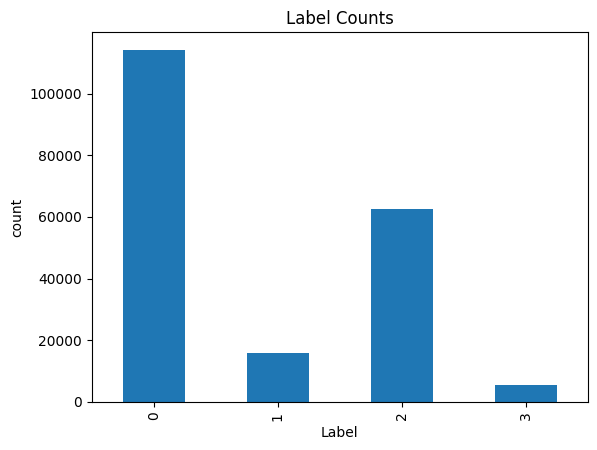

In [17]:
train['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Label Counts')
plt.xlabel("Label")
plt.ylabel("count")
plt.show()

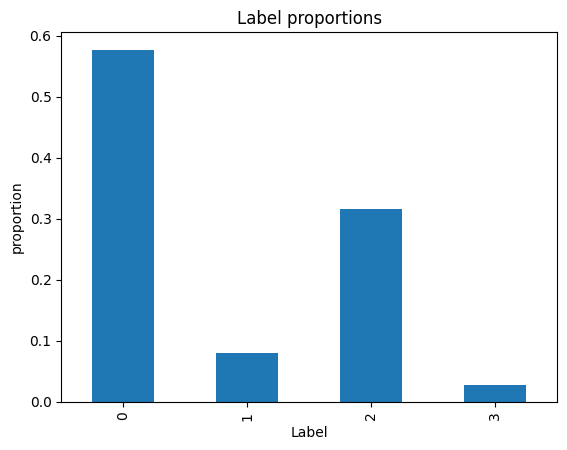

In [18]:
train['label'].value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Label proportions')
plt.xlabel("Label")
plt.ylabel("proportion")
plt.show()

In [19]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

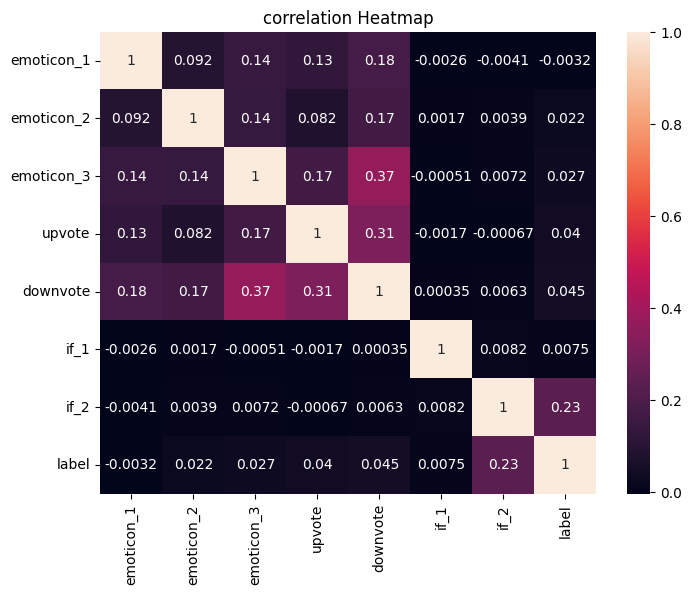

In [20]:
num_cols_eda = ['emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2','label']

plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols_eda].corr(),annot=True)
plt.title("correlation Heatmap")
plt.show()

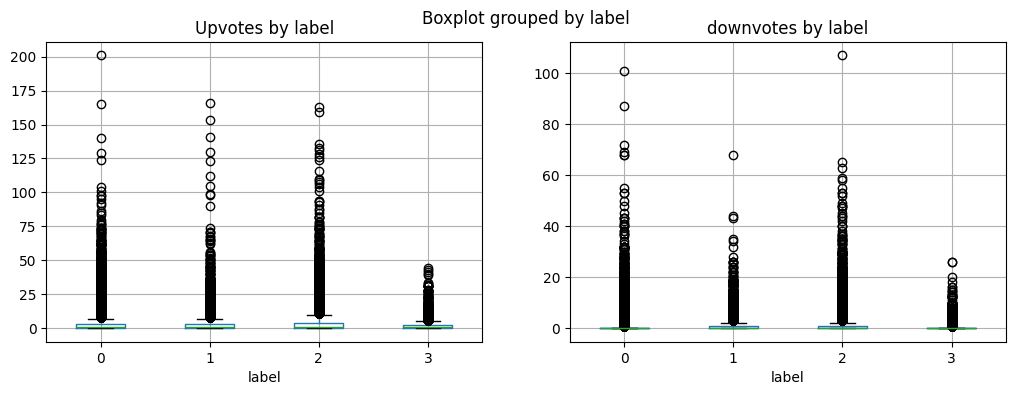

In [21]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

train.boxplot(column='upvote',by='label',ax=ax[0])
ax[0].set_title("Upvotes by label")

train.boxplot(column='downvote',by='label',ax=ax[1])
ax[1].set_title("downvotes by label")

plt.show()

## 1.4 Statistical Ananlysis

In [22]:
train[num_cols_eda].describe()

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [23]:
train['comm_len'] = train['comment'].astype(str).apply(len)
train.groupby('label')['comm_len'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,295.897279,269.586161,1.0,93.0,199.0,411.0,1892.0
1,15918.0,335.709700,267.543579,6.0,129.0,246.0,465.0,1006.0
2,62440.0,316.893418,262.830082,3.0,117.0,232.0,437.0,1006.0
3,5469.0,194.171695,194.253112,7.0,68.0,128.0,245.0,1005.0


## EDA Insights:
- Train has **198k rows** and Test has **102k rows**
- label distribution is imbalanced: **class 0 (57%), class 2 (31%), class 1 (8%), class 3 (2.7%)**
- race,religion,gender --> **145k null** values each
- comment column has **1 null** in train
- post_id has only **52 Unique Values** (More like categorical group feature)


## 1.5 Data Cleaning and preprocessing

In [24]:
train.drop(columns=['comm_len'],inplace=True)

In [25]:
train.fillna({'race':'unknown','religion':'unknown','gender':'unknown'},inplace=True)
test.fillna({'race':'unknown','religion':'unknown','gender':'unknown'},inplace=True)

train['comment'] = train['comment'].fillna('')
test['comment'] = test['comment'].fillna('')

In [26]:
train.isna().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
dtype: int64

## 1.6 Feature Engineering
- uniq_ratio -> Complexity (Spam vs Intellectual)
- caps_ratio -> Aggression 
- excl_count -> Emotion 
- avg_wlen -> Depth (Formal/Political)
- word_count, ques_count, punc_ratio -> more text stats
- down_up_ratio & total_votes -> Controversy Score
- if2_bin --> divides into 3 classes ('low','mid','high')

In [27]:
def uniq_ratio(text):
    text = str(text).lower()
    words = text.split()
    if len(words) == 0:
        return 0
    unique_words = set(words)
    return len(unique_words) / len(words)

train['uniq_ratio'] = train['comment'].apply(uniq_ratio)
test['uniq_ratio'] = test['comment'].apply(uniq_ratio)

In [28]:
def caps_ratio(text):
    text = str(text)          
    total_chars = len(text)  
    if total_chars == 0:
        return 0
    
    caps_count = 0
    for c in text:
        if c.isupper():
            caps_count += 1

    return caps_count / total_chars

train['caps_ratio'] = train['comment'].apply(caps_ratio)
test['caps_ratio'] = test['comment'].apply(caps_ratio)

In [29]:
def excl_count(text):
    text = str(text)
    count = 0
    for ch in text:
        if ch == '!':
            count += 1
    return count

train['excl_count'] = train['comment'].apply(excl_count)
test['excl_count'] = test['comment'].apply(excl_count)

In [30]:
def avg_wlen(text):
    text = str(text)         
    words = text.split()     

    if len(words) == 0:
        return 0

    total_length = 0
    for w in words:
        total_length += len(w)

    return total_length / len(words)

train['avg_wlen'] = train['comment'].apply(avg_wlen)
test['avg_wlen'] = test['comment'].apply(avg_wlen)

In [31]:
import string

def word_count(text):
    words = str(text).split()
    return len(words)

train['word_count'] = train['comment'].apply(word_count)
test['word_count'] = test['comment'].apply(word_count)

def ques_count(text):
    text = str(text)
    count = 0
    for ch in text:
        if ch == '?':
            count += 1
    return count

train['ques_count'] = train['comment'].apply(ques_count)
test['ques_count'] = test['comment'].apply(ques_count)

def punc_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0
    count = 0
    for ch in text:
        if ch in string.punctuation:
            count += 1
    return count / len(text)

train['punc_ratio'] = train['comment'].apply(punc_ratio)
test['punc_ratio'] = test['comment'].apply(punc_ratio)

In [32]:
train['down_up_ratio'] = train['downvote'] / (train['upvote'] + 1)
test['down_up_ratio'] = test['downvote'] / (test['upvote'] + 1)

train['total_votes'] = train['upvote'] + train['downvote']
test['total_votes'] = test['upvote'] + test['downvote']

In [33]:
train['if2_bin'] = pd.cut(train['if_2'], bins=[-1,4,8,2000], labels=['low','mid','high'])
test['if2_bin'] = pd.cut(test['if_2'], bins=[-1,4,8,2000], labels=['low','mid','high'])

## Comments column cleaning

In [34]:
import re

In [35]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text) 
    text = re.sub(r'@\w+', 'usermention', text) 
    text = re.sub(r'#(\w+)', r'hashtag \1', text) 
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    text = re.sub(r'[^a-z\s!?]', '', text) 
    return text.strip()


train['comment'] = train['comment'].apply(clean_text)
test['comment'] = test['comment'].apply(clean_text)

In [36]:
train['comment'] = train['comment'].replace({"":'neutral'})
test['comment'] = test['comment'].replace({"":'neutral'})

## 1.7 Pipeline Setup

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score

In [38]:
X = train.drop(columns='label')
y = train['label']

In [39]:
num_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 
    'uniq_ratio', 'caps_ratio', 'excl_count', 'avg_wlen',
    'upvote', 'downvote', 'down_up_ratio', 'total_votes',
    'word_count', 'ques_count', 'punc_ratio']

cat_cols = ['race', 'religion', 'gender', 'disability', 'post_id',"if2_bin"]

In [40]:
tfidf_w = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=80000,
    min_df=5,
    sublinear_tf=True,
    lowercase=True
)

tfidf_c = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=80000,
    min_df=5,
    sublinear_tf=True,
    lowercase=True
)

tfidf = FeatureUnion([
    ('word',tfidf_w),
    ('char',tfidf_c)
])

ct = ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('scale',StandardScaler(),num_cols),
    ('tfidf',tfidf,'comment')
],remainder='drop',verbose_feature_names_out=False)

## 1.8 Train-Validation Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

In [42]:
X_train_t = ct.fit_transform(X_train)
X_test_t = ct.transform(X_test)
print('Feature matrix shape:', X_train_t.shape)

Feature matrix shape: (138600, 160094)


## 1.9: Baseline Model : Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
lr = LogisticRegression(
    C=0.5, class_weight='balanced', solver='saga', penalty='l2',
    max_iter=1000, n_jobs=-1, random_state=42
)
lr.fit(X_train_t, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42, solver='saga')

In [45]:
y_pred_lr = lr.predict(X_test_t)
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     34252
           1       0.70      0.86      0.77      4775
           2       0.89      0.84      0.87     18732
           3       0.50      0.81      0.62      1641

    accuracy                           0.90     59400
   macro avg       0.77      0.86      0.80     59400
weighted avg       0.91      0.90      0.90     59400



# Milestone 2: Linear Models,SGD and Hyperparameter Tuning
- Linear Models
- Stochastic Gradient Descent
- Tune the hyperparameters

## 2.1 SGD Classifier

In [46]:
from sklearn.linear_model import SGDClassifier

In [47]:
sgd = SGDClassifier(random_state=42, class_weight='balanced')
sgd.fit(X_train_t, y_train)

SGDClassifier(class_weight='balanced', random_state=42)

In [48]:
y_pred_sgd = sgd.predict(X_test_t)
sgd_f1 = f1_score(y_test, y_pred_sgd, average='macro')
print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     34252
           1       0.72      0.81      0.76      4775
           2       0.87      0.85      0.86     18732
           3       0.63      0.68      0.65      1641

    accuracy                           0.90     59400
   macro avg       0.79      0.82      0.81     59400
weighted avg       0.90      0.90      0.90     59400



## 2.2 Hyperparameter Tuning for SGD

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
sgd_model = SGDClassifier(random_state=42, class_weight='balanced', loss='modified_huber')

params = [
    {
        'learning_rate': ['optimal'],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'alpha': [1e-4, 1e-3, 1e-2]
    },
    {
        'learning_rate': ['adaptive'],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'alpha': [1e-4, 1e-3, 1e-2],
        'eta0': [0.001, 0.05, 0.1]
    }
]

gscv = GridSearchCV(
    sgd_model, params, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
gscv.fit(X_train_t, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=SGDClassifier(class_weight='balanced',
                                     loss='modified_huber', random_state=42),
             n_jobs=-1,
             param_grid=[{'alpha': [0.0001, 0.001, 0.01],
                          'learning_rate': ['optimal'],
                          'penalty': ['l2', 'l1', 'elasticnet']},
                         {'alpha': [0.0001, 0.001, 0.01],
                          'eta0': [0.001, 0.05, 0.1],
                          'learning_rate': ['adaptive'],
                          'penalty': ['l2', 'l1', 'elasticnet']}],
             scoring='f1_macro', verbose=1)

In [51]:
print(gscv.best_params_)
sgd_tuned_f1 = f1_score(y_test, gscv.predict(X_test_t), average='macro')
print('SGD tuned F1 Macro:', round(sgd_tuned_f1, 4))

{'alpha': 0.0001, 'eta0': 0.05, 'learning_rate': 'adaptive', 'penalty': 'elasticnet'}
SGD tuned F1 Macro: 0.8265


---
# Milestone 3: Dimensionality Reduction, NB/KNN/SVM

- Dimensionality Reduction
- Retrain the models
- Naive Bayes
- Nearest Neighbors
- Support Vector Machines

## 3.1 Dimensionality Reduction with TruncatedSVD

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [53]:
svd = TruncatedSVD(n_components=300, random_state=42)

lr_svd = Pipeline([
    ('prep', ct),
    ('svd', svd),
    ('model', LogisticRegression(
        C=0.5,
        class_weight='balanced',
        max_iter=4000,
        random_state=42
    ))
])

lr_svd.fit(X_train, y_train)

lr_svd_pred = lr_svd.predict(X_test)

lr_svd_f1 = f1_score(y_test, lr_svd_pred, average='macro')
print("LR + SVD F1:", round(lr_svd_f1,4))

LR + SVD F1: 0.7138


## 3.2 Naive Bayes

In [54]:
from sklearn.naive_bayes import MultinomialNB
import numpy as np
from sklearn.preprocessing import FunctionTransformer

make_positive = FunctionTransformer(
    lambda x: np.abs(x),
    accept_sparse=True
)

In [55]:
nb = Pipeline([
    ('prep', ct),             
    ('abs', make_positive),
    ('model', MultinomialNB(alpha=1.0))
])

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_f1 = f1_score(y_test, nb_pred, average='macro')
print("Naive Bayes F1 Macro:", round(nb_f1,4))

Naive Bayes F1 Macro: 0.6197


## 3.3 K-Nearest Neighbors

In [56]:
from sklearn.neighbors import KNeighborsClassifier

In [57]:
knn = Pipeline([
    ('prep', ct),
    ('svd', TruncatedSVD(n_components=250, random_state=42)),
    ('model', KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_f1 = f1_score(y_test, knn_pred, average='macro')
print('KNN + SVD F1 Macro:', round(knn_f1, 4))

KNN + SVD F1 Macro: 0.5955


## 3.4 Support Vector Machine

In [58]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

In [59]:
svc = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', dual=False, max_iter=2000),
    method='sigmoid', cv=2
)

svc.fit(X_train_t, y_train)
y_pred_svc = svc.predict(X_test_t)
svc_f1 = f1_score(y_test, y_pred_svc, average='macro')
print('LinearSVC F1 Macro:', round(svc_f1, 4))

LinearSVC F1 Macro: 0.8138


---
# Milestone 4: Ensemble Methods and Multi-Layer Perceptron

- Ensemble (Bagging, Boosting, Stacking)
- Multi-layer Perceptron

## 4.1 Bagging

In [60]:
from sklearn.ensemble import BaggingClassifier

In [61]:
bag = BaggingClassifier(
    estimator=LogisticRegression(class_weight='balanced', max_iter=2000,random_state=42),
    n_estimators=6, random_state=42, n_jobs=-1
)

bag.fit(X_train_t, y_train)

y_pred_bag = bag.predict(X_test_t)
bag_f1 = f1_score(y_test, y_pred_bag, average='macro')

print('Bagging (LR) F1 Macro:', round(bag_f1, 4))

Bagging (LR) F1 Macro: 0.8235


## 4.2 Boosting

In [62]:
from lightgbm import LGBMClassifier

In [63]:
lgbm = LGBMClassifier(
    n_estimators=50, max_depth=4, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1,class_weight='balanced'
)

lgbm.fit(X_train_t, y_train)
y_pred_lgbm = lgbm.predict(X_test_t)

lgbm_f1 = f1_score(y_test, y_pred_lgbm, average='macro')
print('LightGBM F1 Macro:', round(lgbm_f1, 4))

LightGBM F1 Macro: 0.7386


## 4.3 Multi-Layer Perceptron

In [64]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ('prep', ct),
    ('svd', TruncatedSVD(n_components=300, random_state=42)),
    ('model', MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=30,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

mlp_pred = mlp.predict(X_test)

mlp_f1 = f1_score(y_test, mlp_pred, average='macro')
print('MLP + SVD F1 Macro:', round(mlp_f1, 4))

MLP + SVD F1 Macro: 0.746


## 4.4 Soft Voting Ensemble(SGD + BaggingLR + SVC)

In [65]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report

In [66]:
lr = LogisticRegression(class_weight='balanced', max_iter=5000,random_state=42)

bag_lr = BaggingClassifier(estimator=lr, n_estimators=12, bootstrap=True,
                           n_jobs=-1, random_state=42)

svc = CalibratedClassifierCV(
    estimator=LinearSVC(class_weight='balanced', dual=False, max_iter=2000, random_state=42),
    method='sigmoid', cv=3
)

sgd = SGDClassifier(class_weight='balanced', alpha=0.0001, loss='modified_huber',
                    learning_rate='adaptive', eta0=0.05, penalty='elasticnet',
                    max_iter=10000, tol=1e-4, random_state=42)

vote = VotingClassifier(
    estimators=[('bag_lr', bag_lr), ('svc', svc), ('sgd', sgd)],
    voting='soft', weights=[2, 3, 5], n_jobs=-1
)

vote.fit(X_train_t, y_train)
y_pred_vote = vote.predict(X_test_t)
vote_f1 = f1_score(y_test, y_pred_vote, average='macro')

print(classification_report(y_test, y_pred_vote))
print("Voting F1 Macro:", round(vote_f1, 4))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     34252
           1       0.77      0.82      0.79      4775
           2       0.87      0.90      0.89     18732
           3       0.70      0.67      0.68      1641

    accuracy                           0.91     59400
   macro avg       0.83      0.83      0.83     59400
weighted avg       0.92      0.91      0.92     59400

Voting F1 Macro: 0.8295


---
# Milestone 5: Final Iteration and Submission

Repeat the ML end-to-end process with insights from above milestones.
Pick the best model, retrain on full data, and generate submission.

## 5.1 Model Comparison

In [67]:
results = {
    'Logistic Regression': lr_f1,
    'SGD': sgd_f1,
    'SGD (Tuned)': sgd_tuned_f1,
    'LR (SVD)': lr_svd_f1,
    'Naive Bayes': nb_f1,
    'KNN': knn_f1,
    'LinearSVC': svc_f1,
    'Bagging (LR)': bag_f1,
    'LightGBM': lgbm_f1,
    'MLP': mlp_f1,
    'Voting (SGD + BaggingLR + SVC)': vote_f1,
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'F1 Macro'])
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
results_df['F1 Macro'] = results_df['F1 Macro'].round(4)
print(results_df.to_string(index=False))

                         Model  F1 Macro
Voting (SGD + BaggingLR + SVC)    0.8295
                   SGD (Tuned)    0.8265
                  Bagging (LR)    0.8235
                     LinearSVC    0.8138
                           SGD    0.8078
           Logistic Regression    0.8033
                           MLP    0.7460
                      LightGBM    0.7386
                      LR (SVD)    0.7138
                   Naive Bayes    0.6197
                           KNN    0.5955


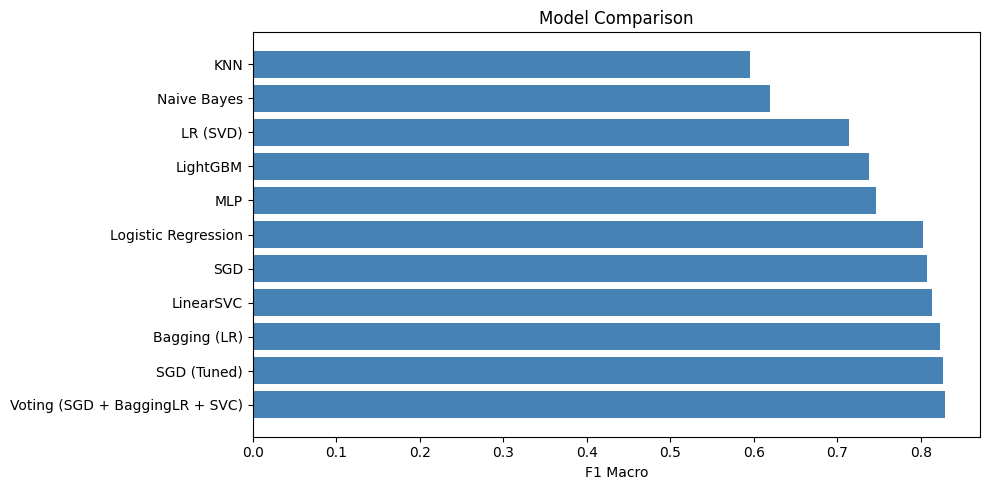

In [68]:
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['F1 Macro'], color='steelblue')
plt.xlabel('F1 Macro')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()

In [69]:
X_full_t = ct.fit_transform(X)
test_t = ct.transform(test)

vote.fit(X_full_t, y)

VotingClassifier(estimators=[('bag_lr',
                              BaggingClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                             max_iter=5000,
                                                                             random_state=42),
                                                n_estimators=12, n_jobs=-1,
                                                random_state=42)),
                             ('svc',
                              CalibratedClassifierCV(cv=3,
                                                     estimator=LinearSVC(class_weight='balanced',
                                                                         dual=False,
                                                                         max_iter=2000,
                                                                         random_state=42))),
                             ('sgd',
                              SGDClassifier(class_weight='balanced', eta0=0.05,
                                            learning_rate='adaptive',
                                            loss='modified_huber',
                                            max_iter=10000,
                                            penalty='elasticnet',
                                            random_state=42, tol=0.0001))],
                 n_jobs=-1, voting='soft', weights=[2, 3, 5])

In [70]:
y_pred = vote.predict(test_t)
submission = pd.DataFrame({"ID": np.arange(1, 102001), "label": y_pred})
submission.to_csv("submission.csv", index=False)

## 5.2 Model Performance Insights

1. **Ensembles are the best**: `Bagging` and `Voting Classifier` gave the best results because they combine multiple models to make fewer mistakes.
2. **Simple Linear Models work well**: `SGDClassifier` and `Logistic Regression` were very fast and gave great results. Text data has a lot of columns, which is easier for linear models to handle.
3. **Tuning helped**: Finding the best parameters for `SGDClassifier` using GridSearchCV actually improved its F1 score.
4. **Other models struggled**: `KNN` and `Naive Bayes` gave the lowest scores. KNN usually doesn't work well when there are too many features.
5. **Neural Networks**: The `MLP` model gave decent results, but it was slightly worse than simple linear models. Simple neural networks sometimes struggle with text data formatted this way.